In [1]:
import os

# 切换到上层文件夹
os.chdir("..")

# 验证
print("当前工作目录:", os.getcwd())

当前工作目录: /Users/sunshine8641/Code/OOD


In [ ]:
# os.environ["CUDA_VISIBLE_DEVICES"]="1"

In [2]:
import os
import torch
import torch.nn as nn
from accelerate import Accelerator
from data_utils.build_dataset import build_id_dataloaders,build_ood_dataloaders,build_jigsaw_dataloaders
from methods import forward_base,calculate_layer_norm
from models import get_model,ParametricBReLU,ParametricBoundedLeakyReLU,BoundedPReLU
from utils import get_args, merge_args_with_config, load_config, accuracy, MetersGroup,\
format_meters_log
from safetensors.torch import load_file
from collections import OrderedDict
from metrics import  *
from  methods import *
import seaborn as sns
from scipy.stats import norm
import matplotlib.pyplot as plt
from train.train_utils import load_clean_model_state
from eval import exp_base,  initialize_experiment
from data_utils.transforms import get_ood_transform,get_id_transform


from utils import *

In [3]:
args = argparse.Namespace()
args.config="configs/base_cifar_resnet.yaml"# get_args()

if args.config:
    cfg = load_config(args.config)
    config = merge_args_with_config(args, cfg)
else:
    config = vars(args)  # 如果没有配置文件，直接用args
print(config)

{'exp_name': 'resnet18_cifar100_relu', 'id_dataset': {'name': 'cifar100', 'root': '/Users/sunshine8641/Code/Data/'}, 'ood_dataset': {'name': 'svhn', 'root': '/Users/sunshine8641/Code/Data/'}, 'top_5': False, 'model': {'type': 'resnet18_cifar', 'pretrained': False, 'num_classes': 100, 'activation': 'relu', 'last_block_activation': 'relu'}, 'num_classes': 100, 'test_model': 'base_best', 'start_epoch': 0, 'epochs': 200, 'lr': 0.1, 'min_lr': 0, 'weight_decay': 5e-05, 'mixed_precision': 'fp16', 'batch_size': 128, 'num_workers': 4, 'momentum': 0.9, 'optimizer': 'SGD', 'scheduler': 'cosine', 'step_gamma': 0.1, 'step_size': 30, 'train_method': 'base', 'use_swa': False, 'swa_window': 40, 'swa_start': 0, 'label_smooth': True, 'smoothing': 0.1, 'teacher': {'type': 'resnet34_cifar', 'pretrained': False, 'num_classes': 100}, 'teacher_path': 'resnet34_base.pt', 'distill_alpha': 0.5, 'distill_temperature': 4.0, 'log': {'log_dir': './logs', 'use_loguru': True}, 'odin_temperature': 1000.0, 'odin_magnit

In [4]:
accelerator,model,criterion,train_meters,test_meters,top_k,id_train_loader,id_test_loader,id_val_loader,ood_loader=initialize_experiment(config)


[Test] Loading OOD Dataloader for svhn...
mps


<h1 style="color:green; text-shadow: 0 0 10px #ff00ff, 0 0 10px #ff00ff">
  Prepare Experiment
</h1>

In [5]:
tr=get_id_transform(cfg['id_dataset']['name'])
for t in tr[0].transforms:
    if isinstance(t, transforms.Normalize):
        print("Mean:", t.mean)
        mean=t.mean
        print("Std:", t.std)
        std=t.std

Mean: (0.5071, 0.4865, 0.4409)
Std: (0.2673, 0.2564, 0.2762)


<h1 style="color:blue; text-shadow: 0 0 10px #ff00ff, 0 0 10px #ff00ff">
  ID DATA SAMPLE
</h1>

ID Train Batch: x.shape=torch.Size([128, 3, 32, 32]), y.shape=torch.Size([128])
图像已保存到: Figs/x.png


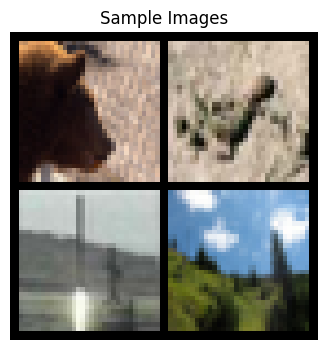

In [6]:
for batch in id_val_loader:
    x, y = batch
    print(f"ID Train Batch: x.shape={x.shape}, y.shape={y.shape}")
    break
show_images(x, y,mean,std, n=4)

In [7]:
#feature norm 计算norm ratio
print("calculating feature norm ratio for feature norm")
calculate_layer_norm(config)

calculating feature norm ratio for feature norm
checkpoints/resnet18_cifar100_relu/base_best/model.pt
ResNet 391 391
NormRatio-Block0: 1.0236663818359375
NormRatio-Block1: 0.968069851398468
NormRatio-Block2: 0.9050027132034302
NormRatio-Block3: 0.8792457580566406
NormRatio-Block4: 0.9600139260292053
NormRatio-Block5: 1.0077637434005737
NormRatio-Block6: 0.9565547108650208
NormRatio-Block7: 0.9779186844825745


In [8]:
model.eval()
test_meters.reset()
with torch.no_grad():
    for inputs, targets in id_test_loader:
        outputs = model(inputs)
        loss = criterion(outputs, targets)
        topk_acc = accuracy(outputs, targets, topk=top_k)
        acc_dict = {f"Acc@{k}": acc.item() for k, acc in zip(top_k, topk_acc)}
        acc_dict["Loss"] = loss.item()
        test_meters.update(acc_dict, n=targets.size(0))
log_str = format_meters_log(0, test_meters.meters,0, None, prefix="Val Epoch")
print(log_str)

Val Epoch 0 | Loss: 1.1945 | Acc@1: 73.70% | Time: 0.00


In [9]:
compute_cadref_stats(config)


[CADRef] Loading model from: checkpoints/resnet18_cifar100_relu/base_best/model.pt
[CADRef] Saved stats to: checkpoints/resnet18_cifar100_relu/base_best/cadref_stats.pt
  - class_centroids shape: torch.Size([100, 512])
  - mean_energy: 18.4300


<h1 style="color:green; text-shadow: 0 0 10px #ff00ff, 0 0 10px #ff00ff">
  OOD Dataset1: SVHN
</h1>

[Test] Loading OOD Dataloader for svhn...
mps
ID Train Batch: x.shape=torch.Size([128, 3, 32, 32])
图像已保存到: Figs/x.png


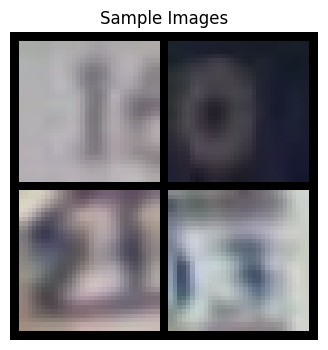

In [10]:
cfg["ood_dataset"]["name"]="svhn"
accelerator,model,criterion,train_meters,test_meters,top_k,id_train_loader,id_test_loader,id_val_loader,ood_loader=initialize_experiment(config)
for batch in ood_loader:
    x, y = batch
    print(f"ID Train Batch: x.shape={x.shape}")
    break
show_images(x, y,mean,std, n=4)

[Test] Loading OOD Dataloader for svhn...
mps
n_iter: 55


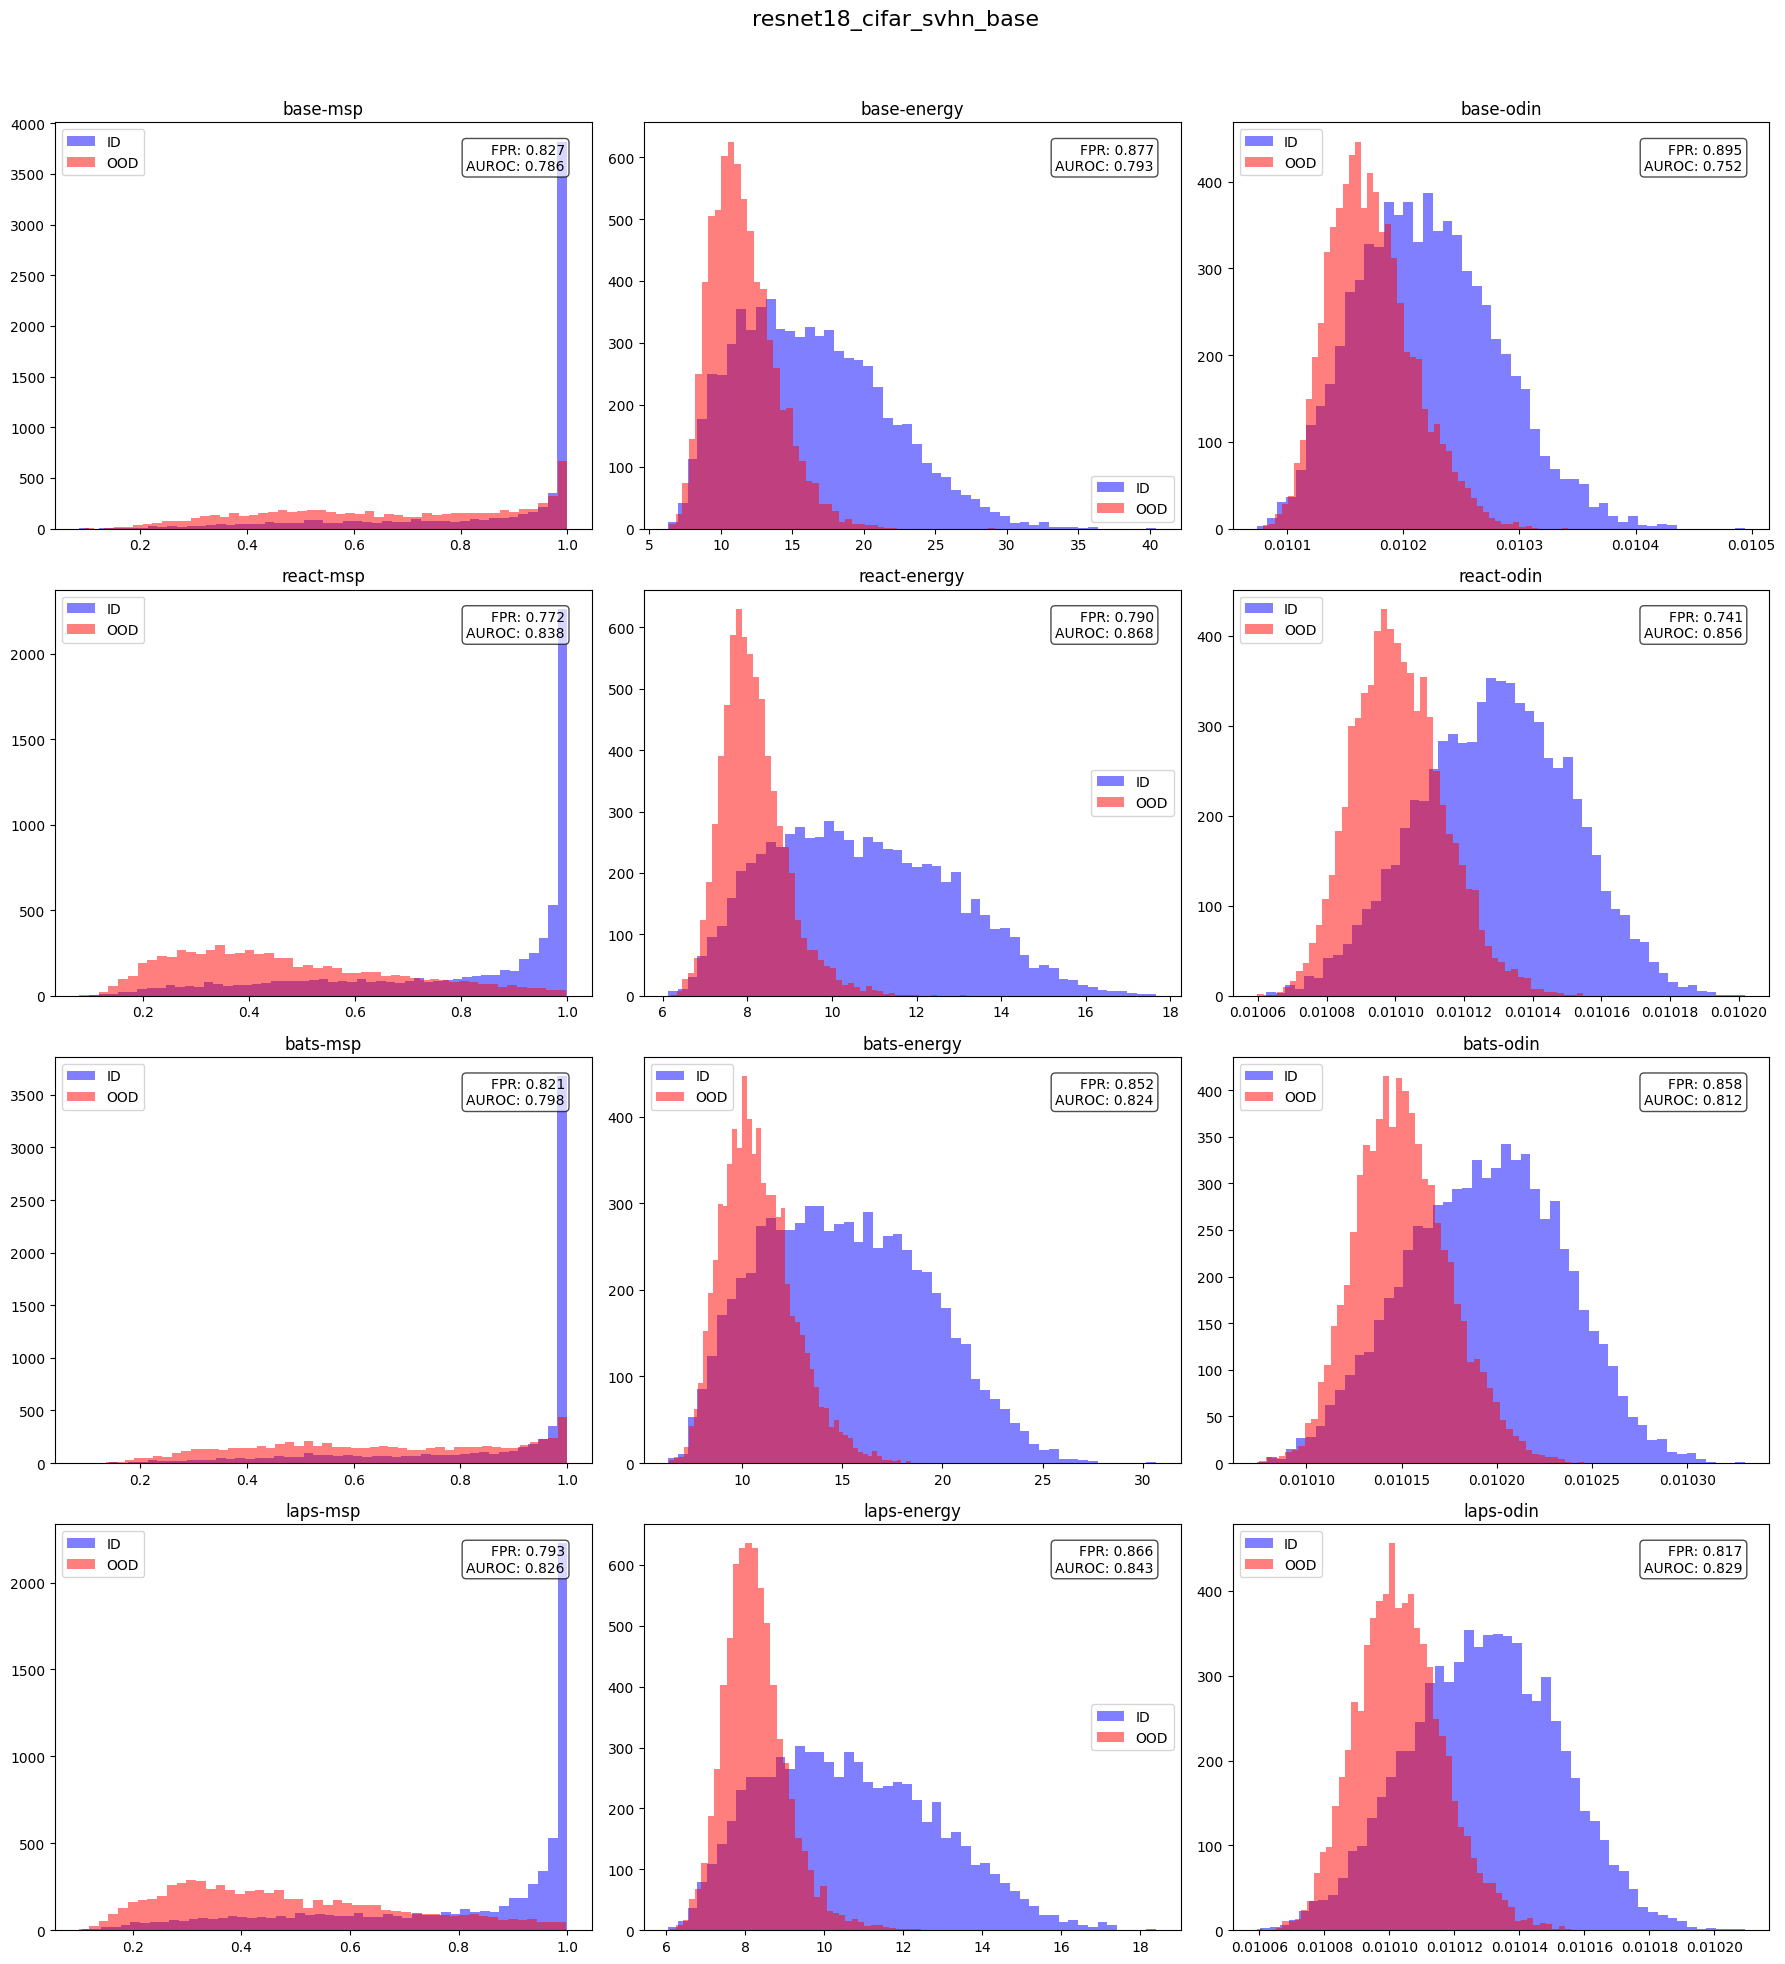

In [13]:
scores_in_all, scores_out_all=exp_base(config,forward_names=["base", "react", "bats", "laps"],methods=["msp", "energy", "odin"])

plot_score_dicts_subplots(scores_in_all, scores_out_all, title="resnet18_cifar_svhn_base")

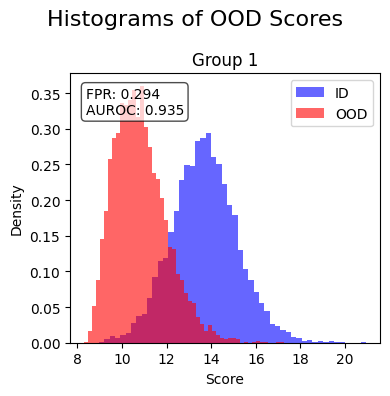

In [14]:
# FeatureNorm Block 0

scores_in_all1=[]
scores_out_all1=[]
config["sblock"]=0
forward_func = get_forward(name="forward_features", config=config)
method="featurenorm"
n_iter=55
scores_in_all_i=get_all_scores( model,id_test_loader, forward_func,method, config, n_iter,accelerator)
scores_out_all_i=get_all_scores( model,ood_loader, forward_func,method, config, n_iter,accelerator)
scores_in_all1.append(scores_in_all_i)
scores_out_all1.append(scores_out_all_i)
plot_histograms(scores_in_all1, scores_out_all1, bins=50, title="Histograms of OOD Scores")


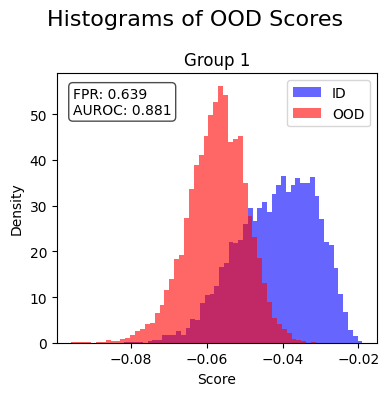

In [12]:
# CADRef 
scores_in_all2=[]
scores_out_all2=[]
config["sblock"]=0
forward_func = get_forward(name="cadref", config=config)
method="cadref"
n_iter=55
scores_in_all_i=get_all_scores( model,id_test_loader, forward_func,method, config, n_iter,accelerator)
scores_out_all_i=get_all_scores( model,ood_loader, forward_func,method, config, n_iter,accelerator)
scores_in_all2.append(scores_in_all_i)
scores_out_all2.append(scores_out_all_i)
plot_histograms(scores_in_all2, scores_out_all2, bins=50, title="Histograms of OOD Scores") 



<h1 style="color:green; text-shadow: 0 0 10px #ff00ff, 0 0 10px #ff00ff">
  OOD Dataset2: Textures
</h1>

[Test] Loading OOD Dataloader for textures...
mps
ID Train Batch: x.shape=torch.Size([128, 3, 32, 32])
图像已保存到: Figs/x.png


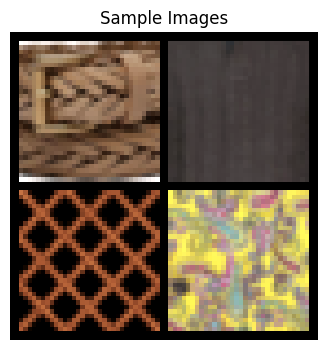

In [15]:
cfg["ood_dataset"]["name"]="textures"
accelerator,model,criterion,train_meters,test_meters,top_k,id_train_loader,id_test_loader,id_val_loader,ood_loader=initialize_experiment(config)
for batch in ood_loader:
    x, y = batch
    print(f"ID Train Batch: x.shape={x.shape}")
    break
show_images(x, y,mean,std, n=4)

[Test] Loading OOD Dataloader for textures...
mps
n_iter: 55


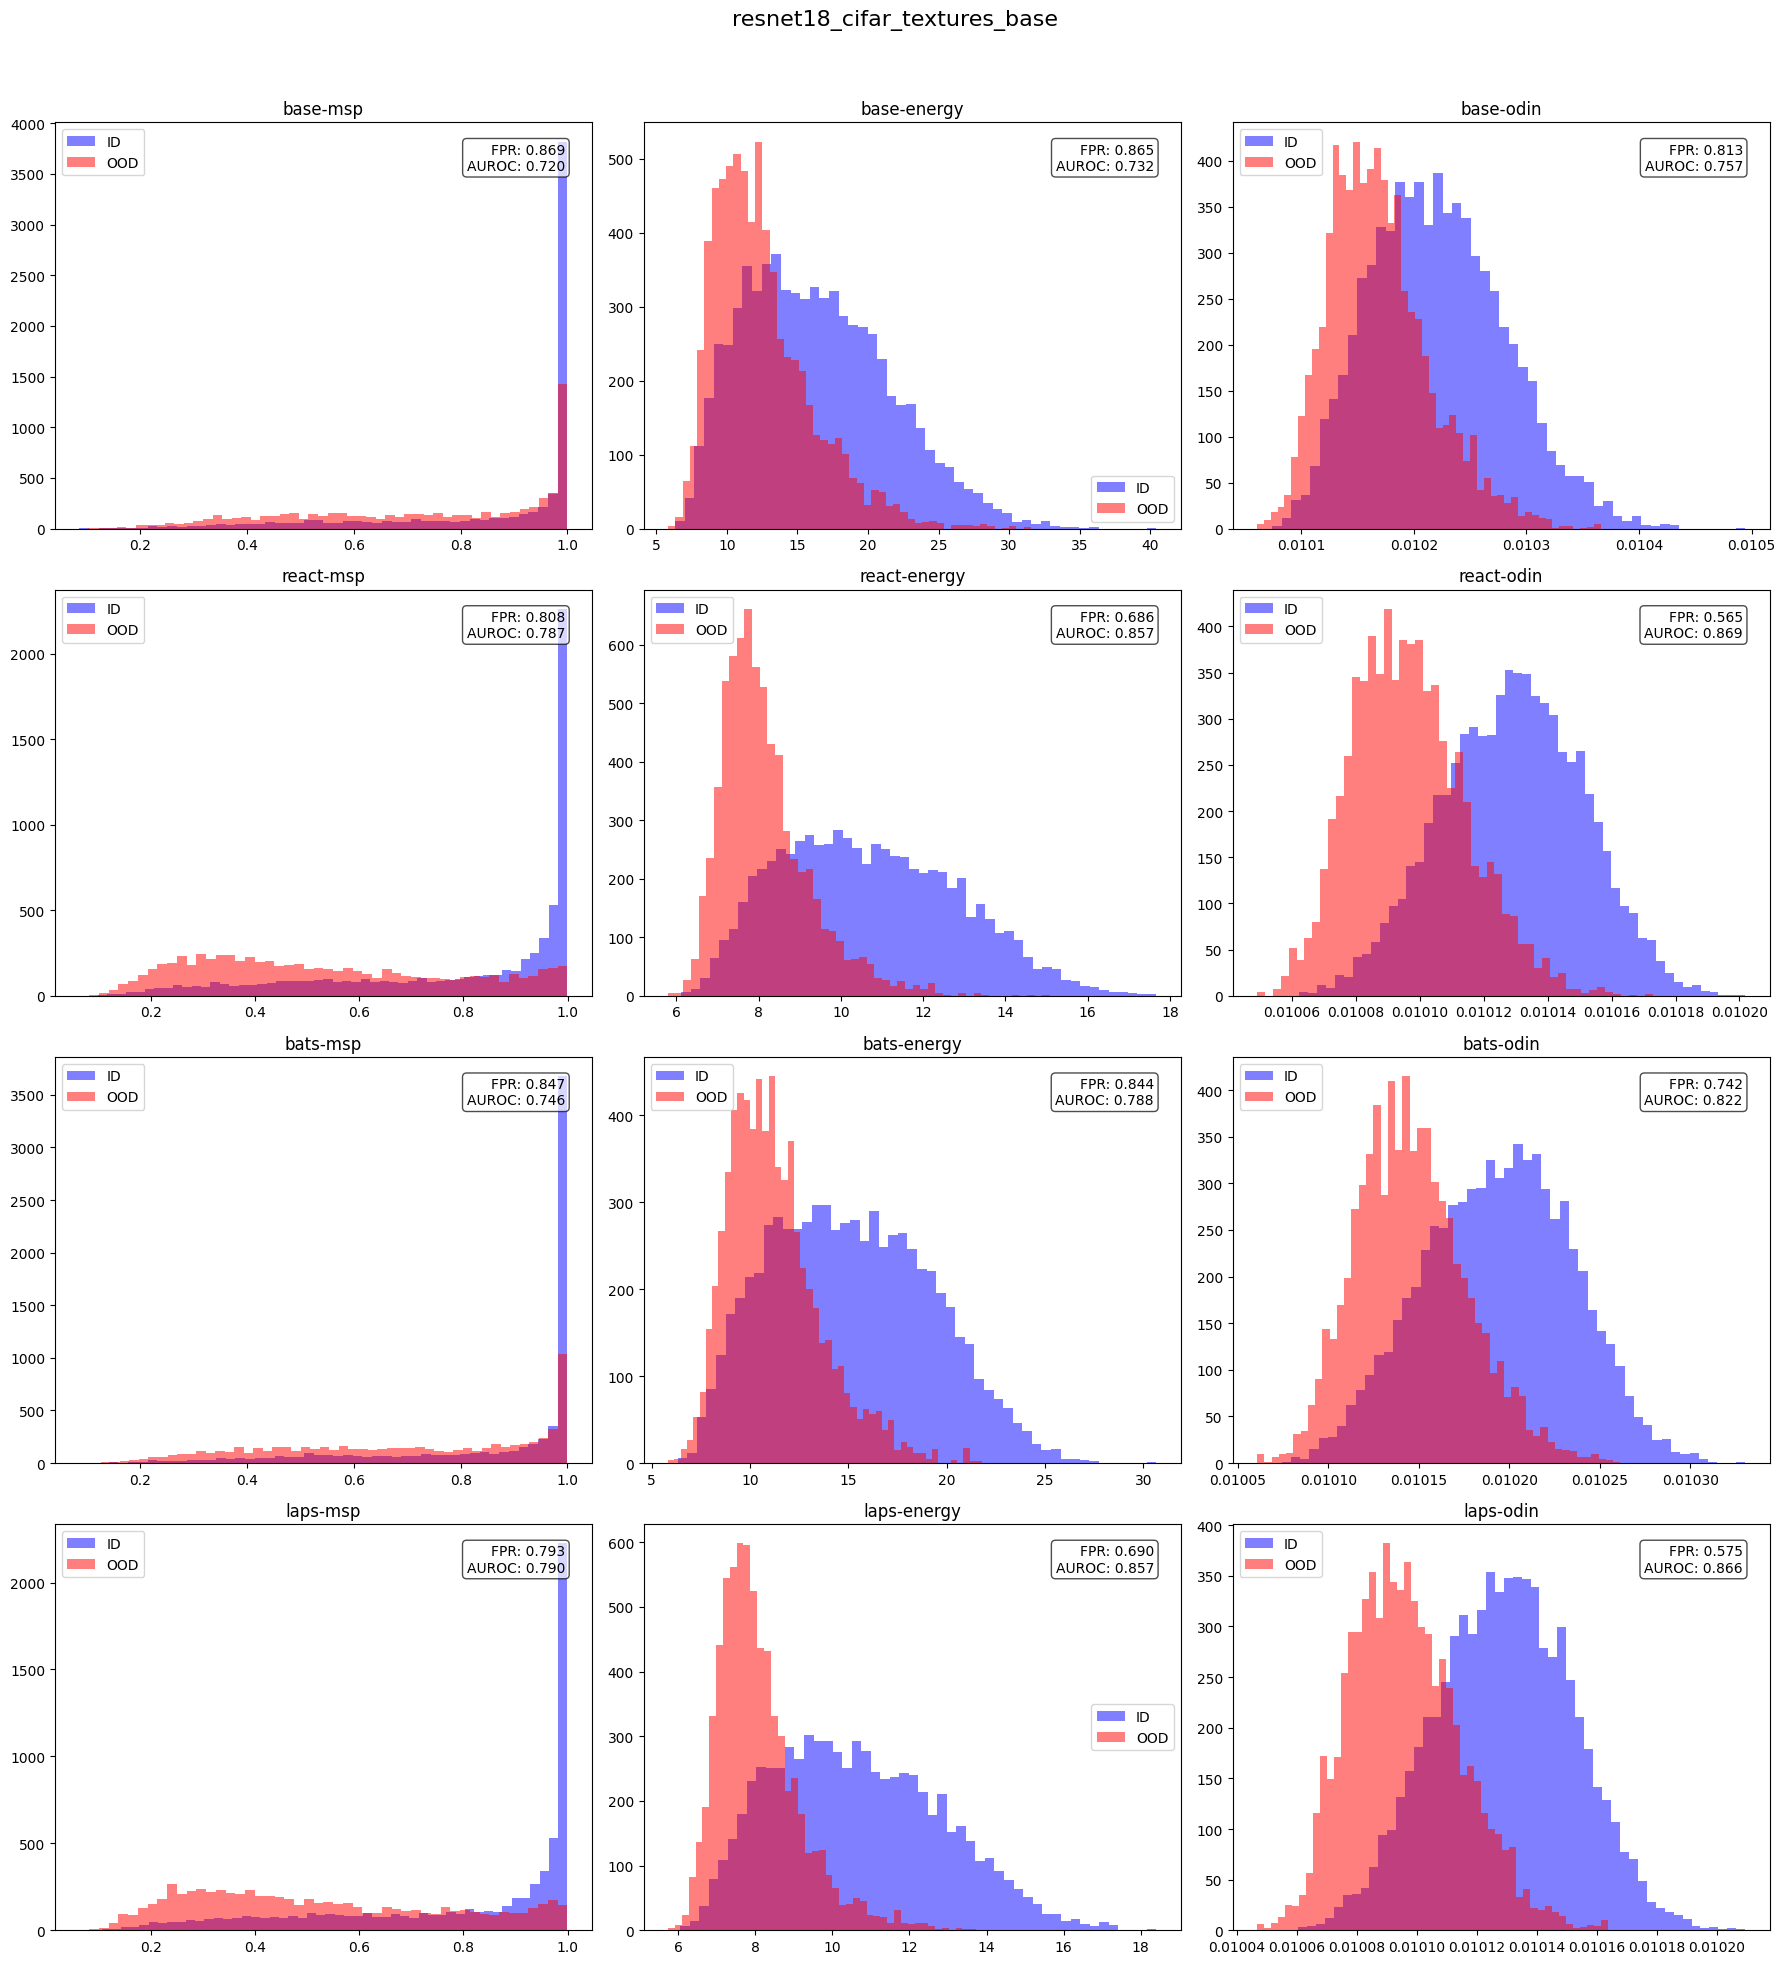

In [16]:
scores_in_all, scores_out_all=exp_base(config,forward_names=["base", "react", "bats", "laps"],methods=["msp", "energy", "odin"])

plot_score_dicts_subplots(scores_in_all, scores_out_all, title="resnet18_cifar_textures_base")

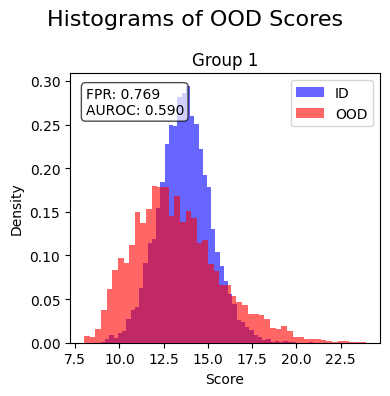

In [17]:
scores_in_all2=[]
scores_out_all2=[]
config["sblock"]=0
forward_func = get_forward(name="forward_features", config=config)
method="featurenorm"
n_iter=55
scores_in_all_i=get_all_scores( model,id_test_loader, forward_func,method, config, n_iter,accelerator)
scores_out_all_i=get_all_scores( model,ood_loader, forward_func,method, config, n_iter,accelerator)
scores_in_all2.append(scores_in_all_i)
scores_out_all2.append(scores_out_all_i)
plot_histograms(scores_in_all2, scores_out_all2, bins=50, title="Histograms of OOD Scores")


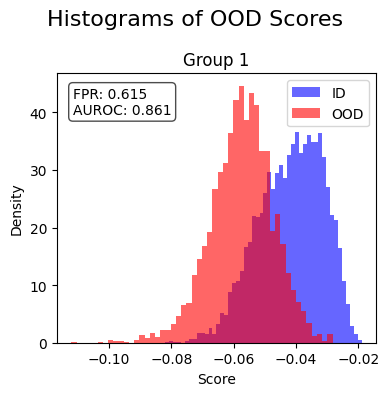

In [18]:
# CADRef 
scores_in_all=[]
scores_out_all=[]
config["sblock"]=0
forward_func = get_forward(name="cadref", config=config)
method="cadref"
n_iter=55
scores_in_all_i=get_all_scores( model,id_test_loader, forward_func,method, config, n_iter,accelerator)
scores_out_all_i=get_all_scores( model,ood_loader, forward_func,method, config, n_iter,accelerator)
scores_in_all.append(scores_in_all_i)
scores_out_all.append(scores_out_all_i)
plot_histograms(scores_in_all, scores_out_all, bins=50, title="Histograms of OOD Scores")   



<h1 style="color:green; text-shadow: 0 0 10px #ff00ff, 0 0 10px #ff00ff">
  OOD Dataset3: LSUN_R
</h1>

[Test] Loading OOD Dataloader for LSUN_R...
/Users/sunshine8641/Code/Data/LSUN_R
mps
ID Train Batch: x.shape=torch.Size([128, 3, 32, 32])
图像已保存到: Figs/x.png


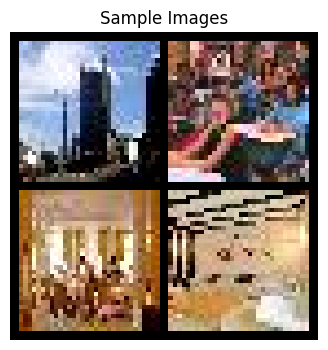

In [20]:
cfg["ood_dataset"]["name"]="LSUN_R"
accelerator,model,criterion,train_meters,test_meters,top_k,id_train_loader,id_test_loader,id_val_loader,ood_loader=initialize_experiment(config)
for batch in ood_loader:
    x, y = batch
    print(f"ID Train Batch: x.shape={x.shape}")
    break
show_images(x, y,mean,std, n=4)

[Test] Loading OOD Dataloader for LSUN_R...
/Users/sunshine8641/Code/Data/LSUN_R
mps
n_iter: 55


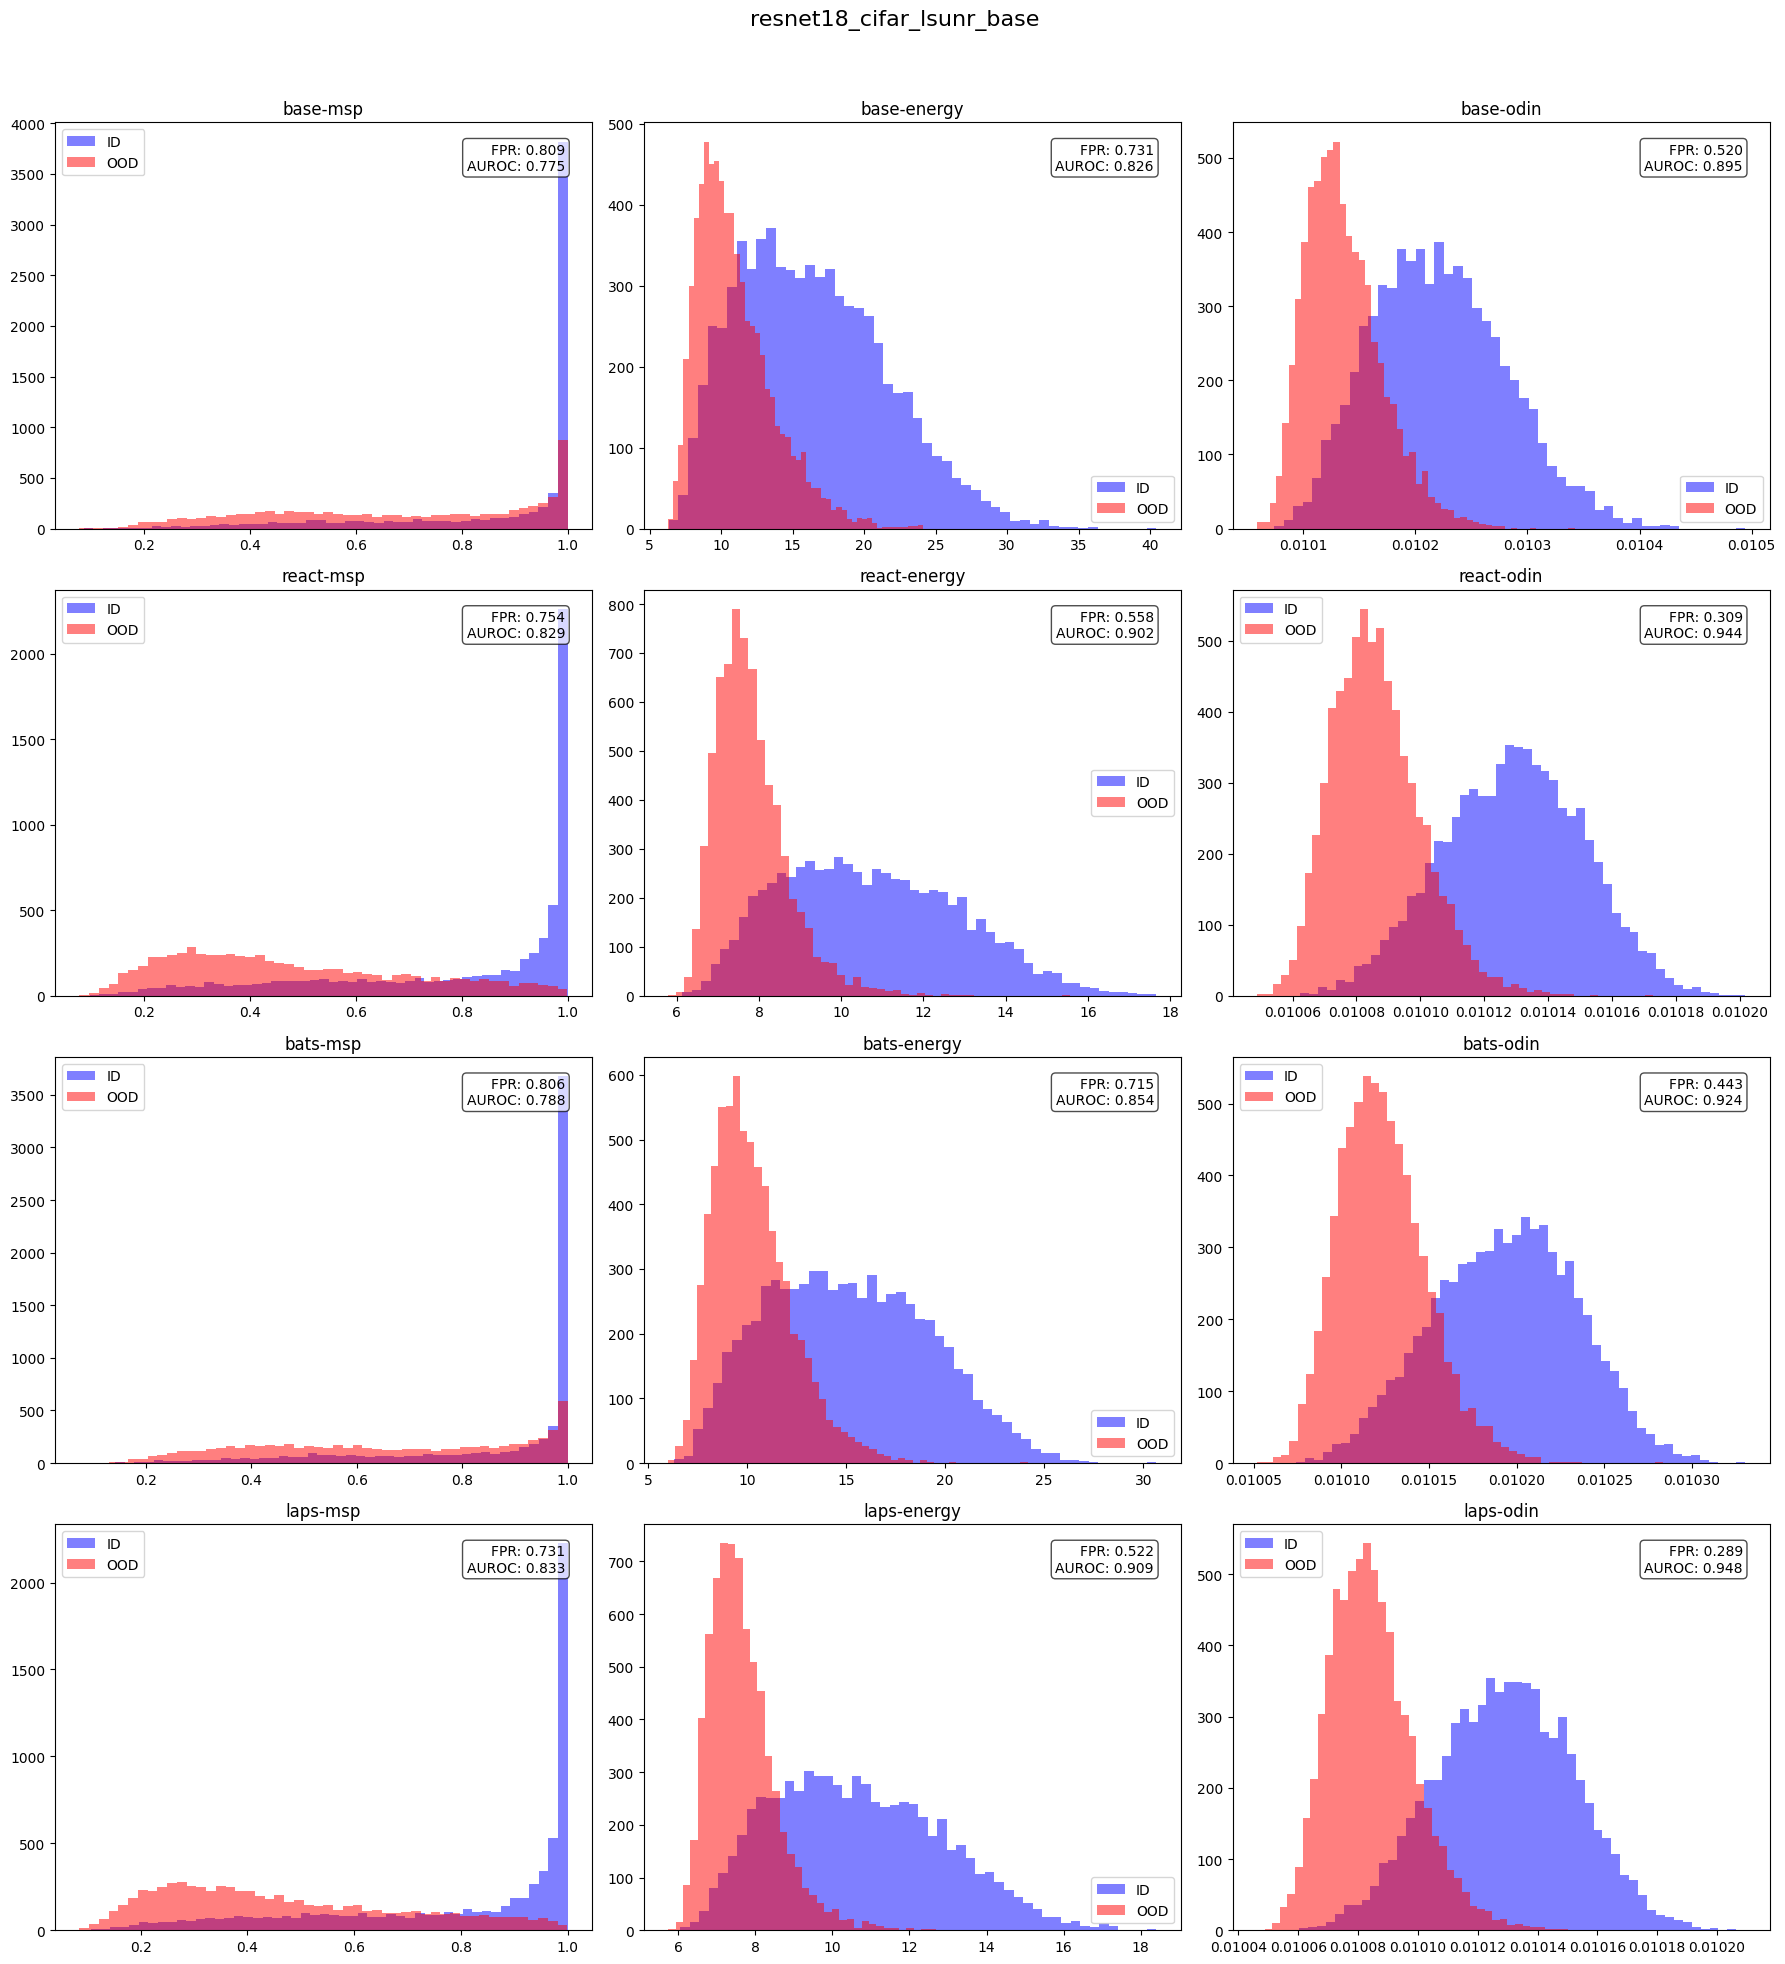

In [21]:
scores_in_all, scores_out_all=exp_base(config,forward_names=["base", "react", "bats", "laps"],methods=["msp", "energy", "odin"])

plot_score_dicts_subplots(scores_in_all, scores_out_all, title="resnet18_cifar_lsunr_base")

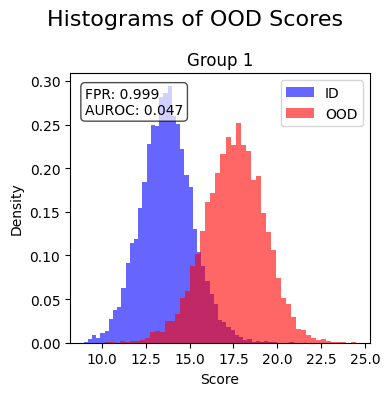

In [22]:
scores_in_all3=[]
scores_out_all3=[]
config["sblock"]=0
forward_func = get_forward(name="forward_features", config=config)
method="featurenorm"
n_iter=55
scores_in_all_i=get_all_scores( model,id_test_loader, forward_func,method, config, n_iter,accelerator)
scores_out_all_i=get_all_scores( model,ood_loader, forward_func,method, config, n_iter,accelerator)
scores_in_all3.append(scores_in_all_i)
scores_out_all3.append(scores_out_all_i)
plot_histograms(scores_in_all3, scores_out_all3, bins=50, title="Histograms of OOD Scores")


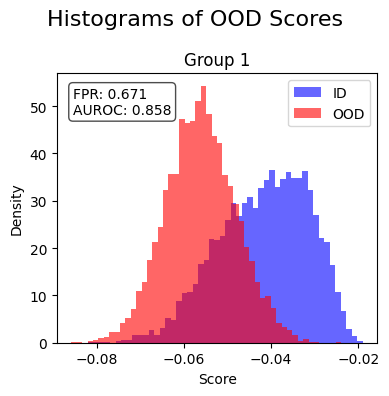

In [23]:
# CADRef 
scores_in_all2=[]
scores_out_all2=[]
config["sblock"]=0
forward_func = get_forward(name="cadref", config=config)
method="cadref"
n_iter=55
scores_in_all_i=get_all_scores( model,id_test_loader, forward_func,method, config, n_iter,accelerator)
scores_out_all_i=get_all_scores( model,ood_loader, forward_func,method, config, n_iter,accelerator)
scores_in_all2.append(scores_in_all_i)
scores_out_all2.append(scores_out_all_i)
plot_histograms(scores_in_all2, scores_out_all2, bins=50, title="Histograms of OOD Scores") 



<h1 style="color:green; text-shadow: 0 0 10px #ff00ff, 0 0 10px #ff00ff">
  OOD Dataset4: LSUN_C
</h1>

[Test] Loading OOD Dataloader for LSUN_C...
/Users/sunshine8641/Code/Data/LSUN_C
mps
ID Train Batch: x.shape=torch.Size([128, 3, 32, 32])
图像已保存到: Figs/x.png


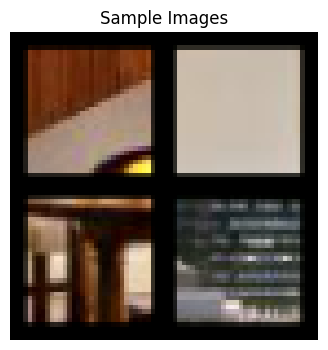

In [24]:
cfg["ood_dataset"]["name"]="LSUN_C"
accelerator,model,criterion,train_meters,test_meters,top_k,id_train_loader,id_test_loader,id_val_loader,ood_loader=initialize_experiment(config)
for batch in ood_loader:
    x, y = batch
    print(f"ID Train Batch: x.shape={x.shape}")
    break
show_images(x, y,mean,std, n=4)

[Test] Loading OOD Dataloader for LSUN_C...
/Users/sunshine8641/Code/Data/LSUN_C
mps
n_iter: 55


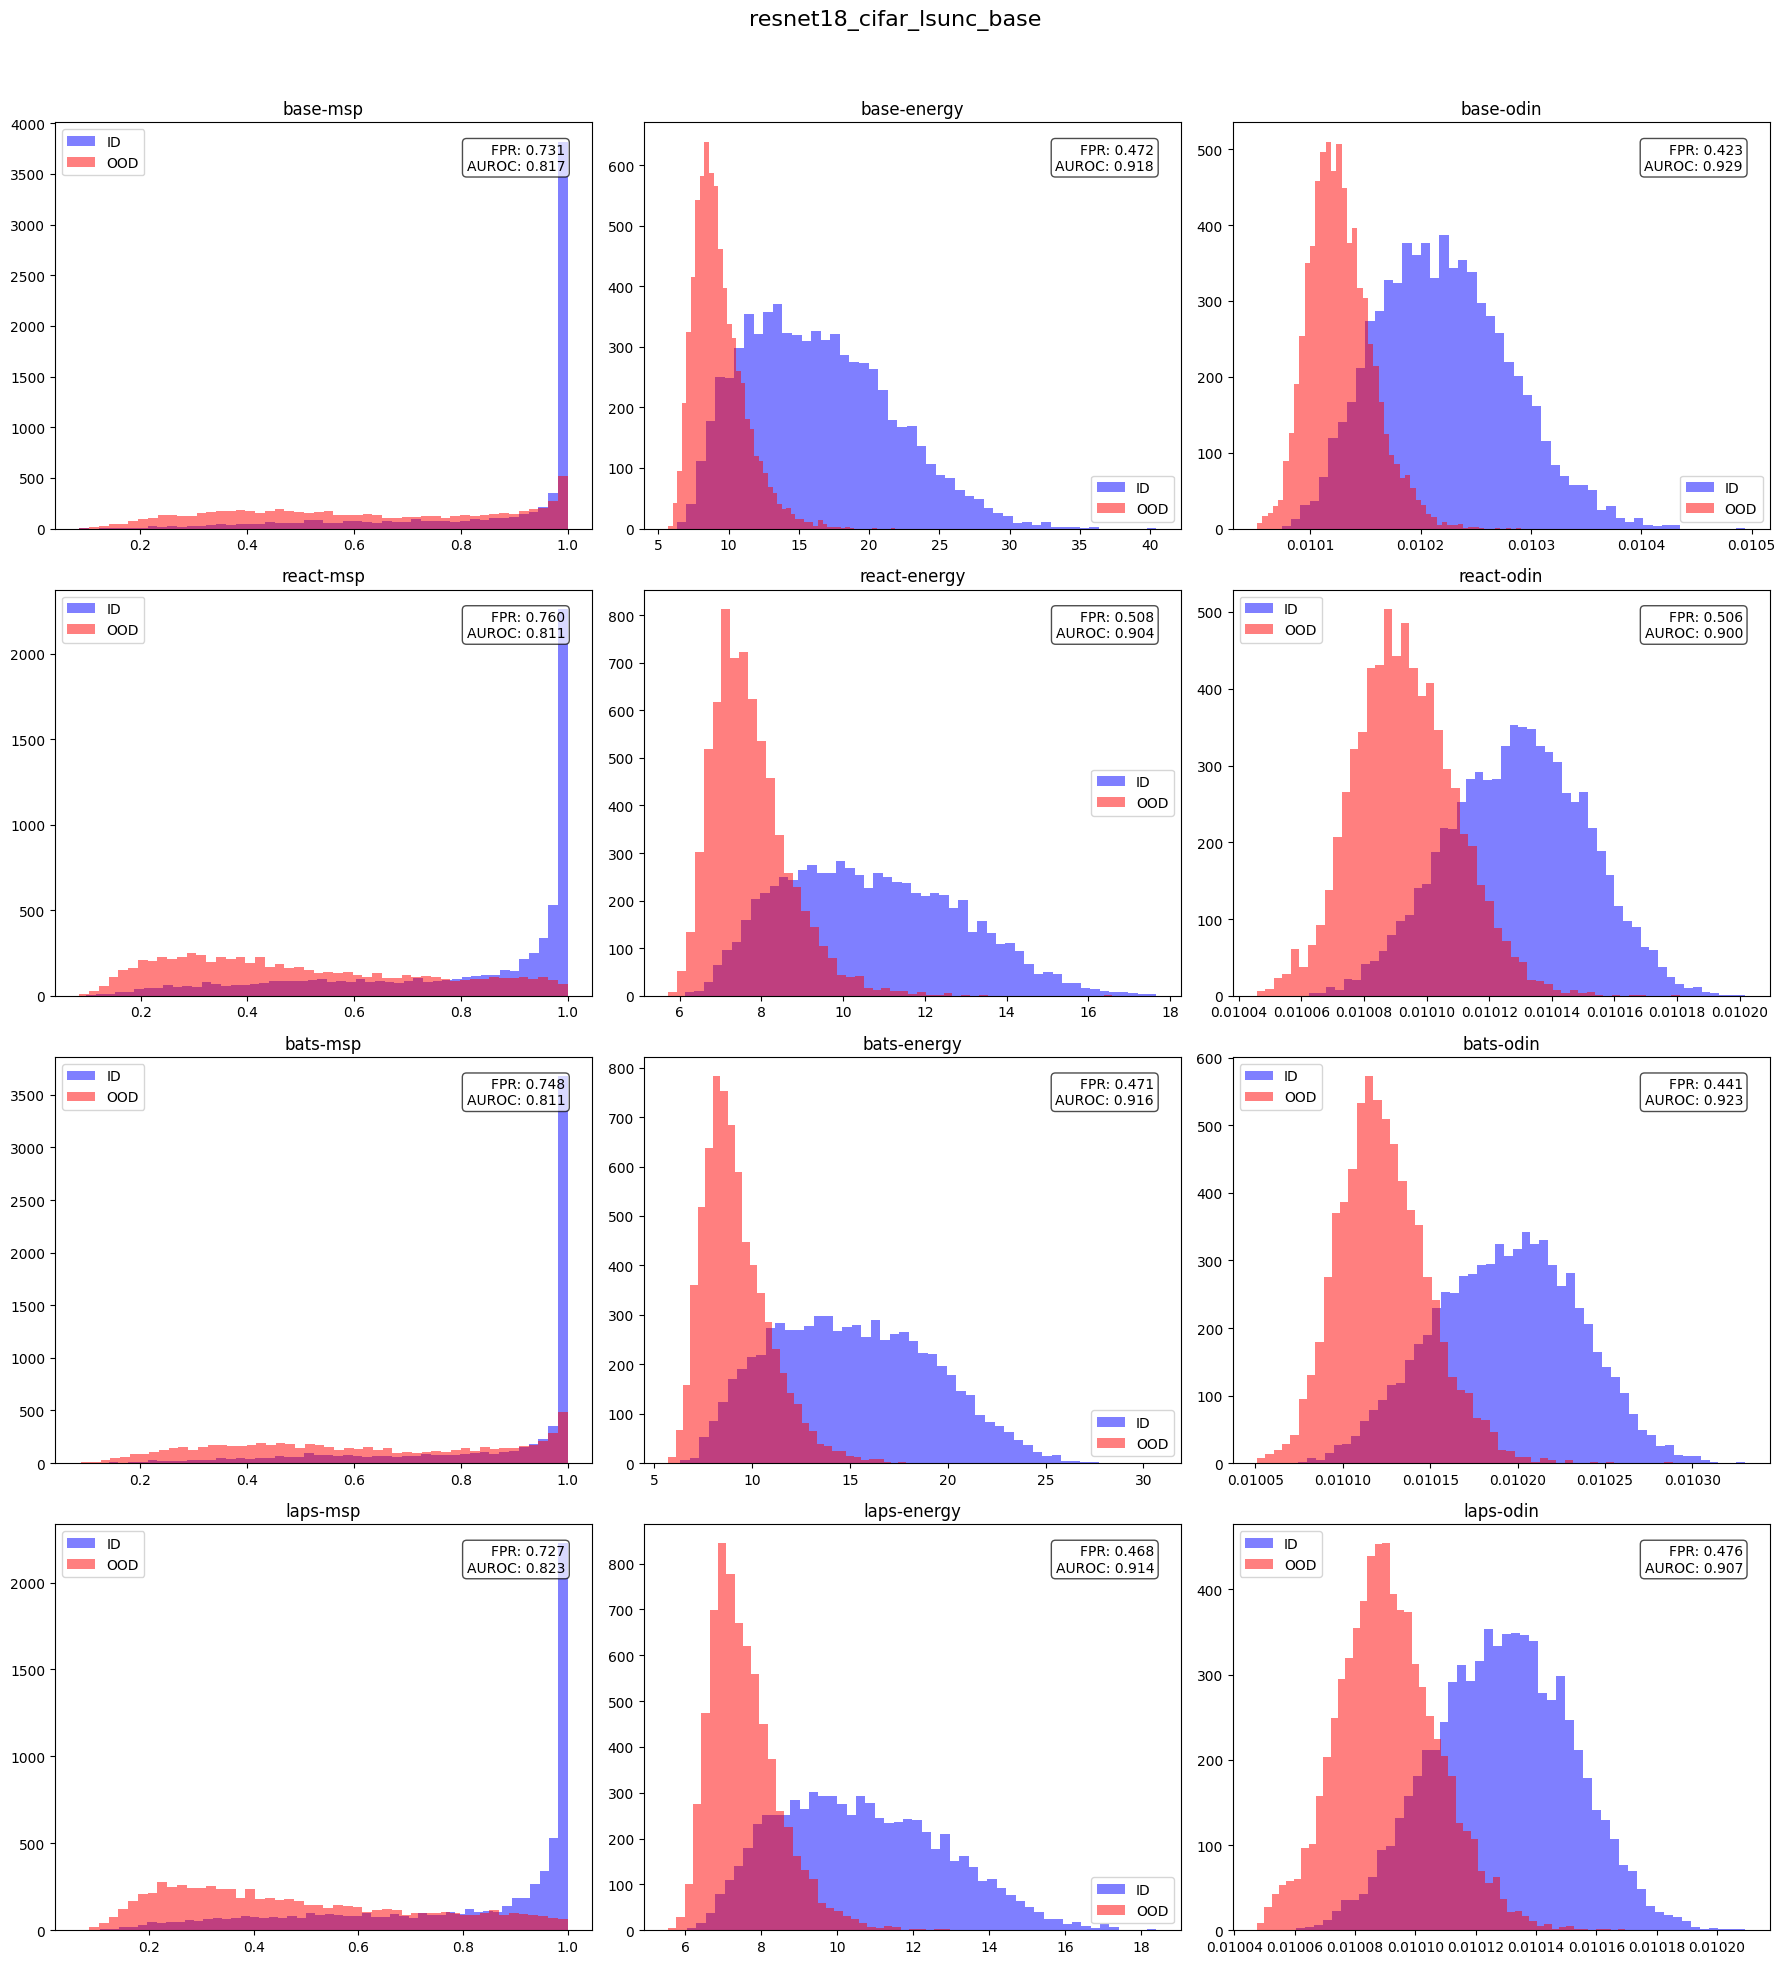

In [25]:
scores_in_all, scores_out_all=exp_base(config,forward_names=["base", "react", "bats", "laps"],methods=["msp", "energy", "odin"])

plot_score_dicts_subplots(scores_in_all, scores_out_all, title="resnet18_cifar_lsunc_base")

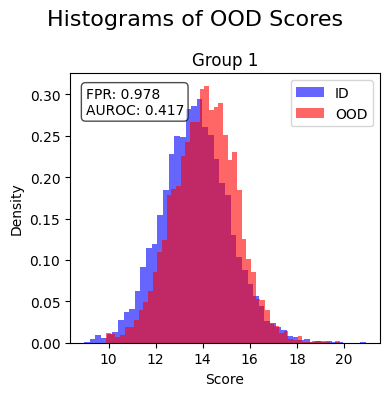

In [26]:
scores_in_all4=[]
scores_out_all4=[]
config["sblock"]=0
forward_func = get_forward(name="forward_features", config=config)
method="featurenorm"
n_iter=55
scores_in_all_i=get_all_scores( model,id_test_loader, forward_func,method, config, n_iter,accelerator)
scores_out_all_i=get_all_scores( model,ood_loader, forward_func,method, config, n_iter,accelerator)
scores_in_all4.append(scores_in_all_i)
scores_out_all4.append(scores_out_all_i)
plot_histograms(scores_in_all4, scores_out_all4, bins=50, title="Histograms of OOD Scores")


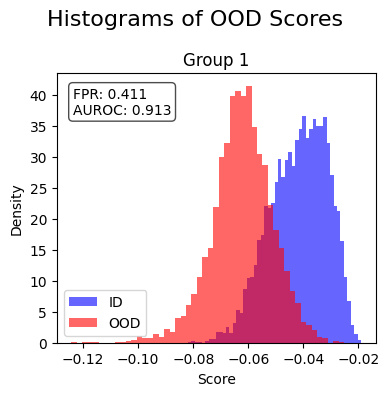

In [27]:
# CADRef 
scores_in_all2=[]
scores_out_all2=[]
config["sblock"]=0
forward_func = get_forward(name="cadref", config=config)
method="cadref"
n_iter=55
scores_in_all_i=get_all_scores( model,id_test_loader, forward_func,method, config, n_iter,accelerator)
scores_out_all_i=get_all_scores( model,ood_loader, forward_func,method, config, n_iter,accelerator)
scores_in_all2.append(scores_in_all_i)
scores_out_all2.append(scores_out_all_i)
plot_histograms(scores_in_all2, scores_out_all2, bins=50, title="Histograms of OOD Scores") 



<h1 style="color:green; text-shadow: 0 0 10px #ff00ff, 0 0 10px #ff00ff">
  OOD Dataset5: iSUN
</h1>

[Test] Loading OOD Dataloader for iSUN...
/Users/sunshine8641/Code/Data/iSUN
mps
ID Train Batch: x.shape=torch.Size([128, 3, 32, 32])
图像已保存到: Figs/x.png


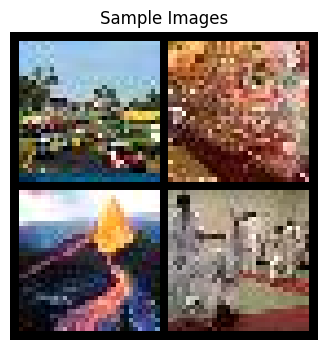

In [28]:
cfg["ood_dataset"]["name"]="iSUN"
accelerator,model,criterion,train_meters,test_meters,top_k,id_train_loader,id_test_loader,id_val_loader,ood_loader=initialize_experiment(config)
for batch in ood_loader:
    x, y = batch
    print(f"ID Train Batch: x.shape={x.shape}")
    break
show_images(x, y,mean,std, n=4)

[Test] Loading OOD Dataloader for iSUN...
/Users/sunshine8641/Code/Data/iSUN
mps
n_iter: 55


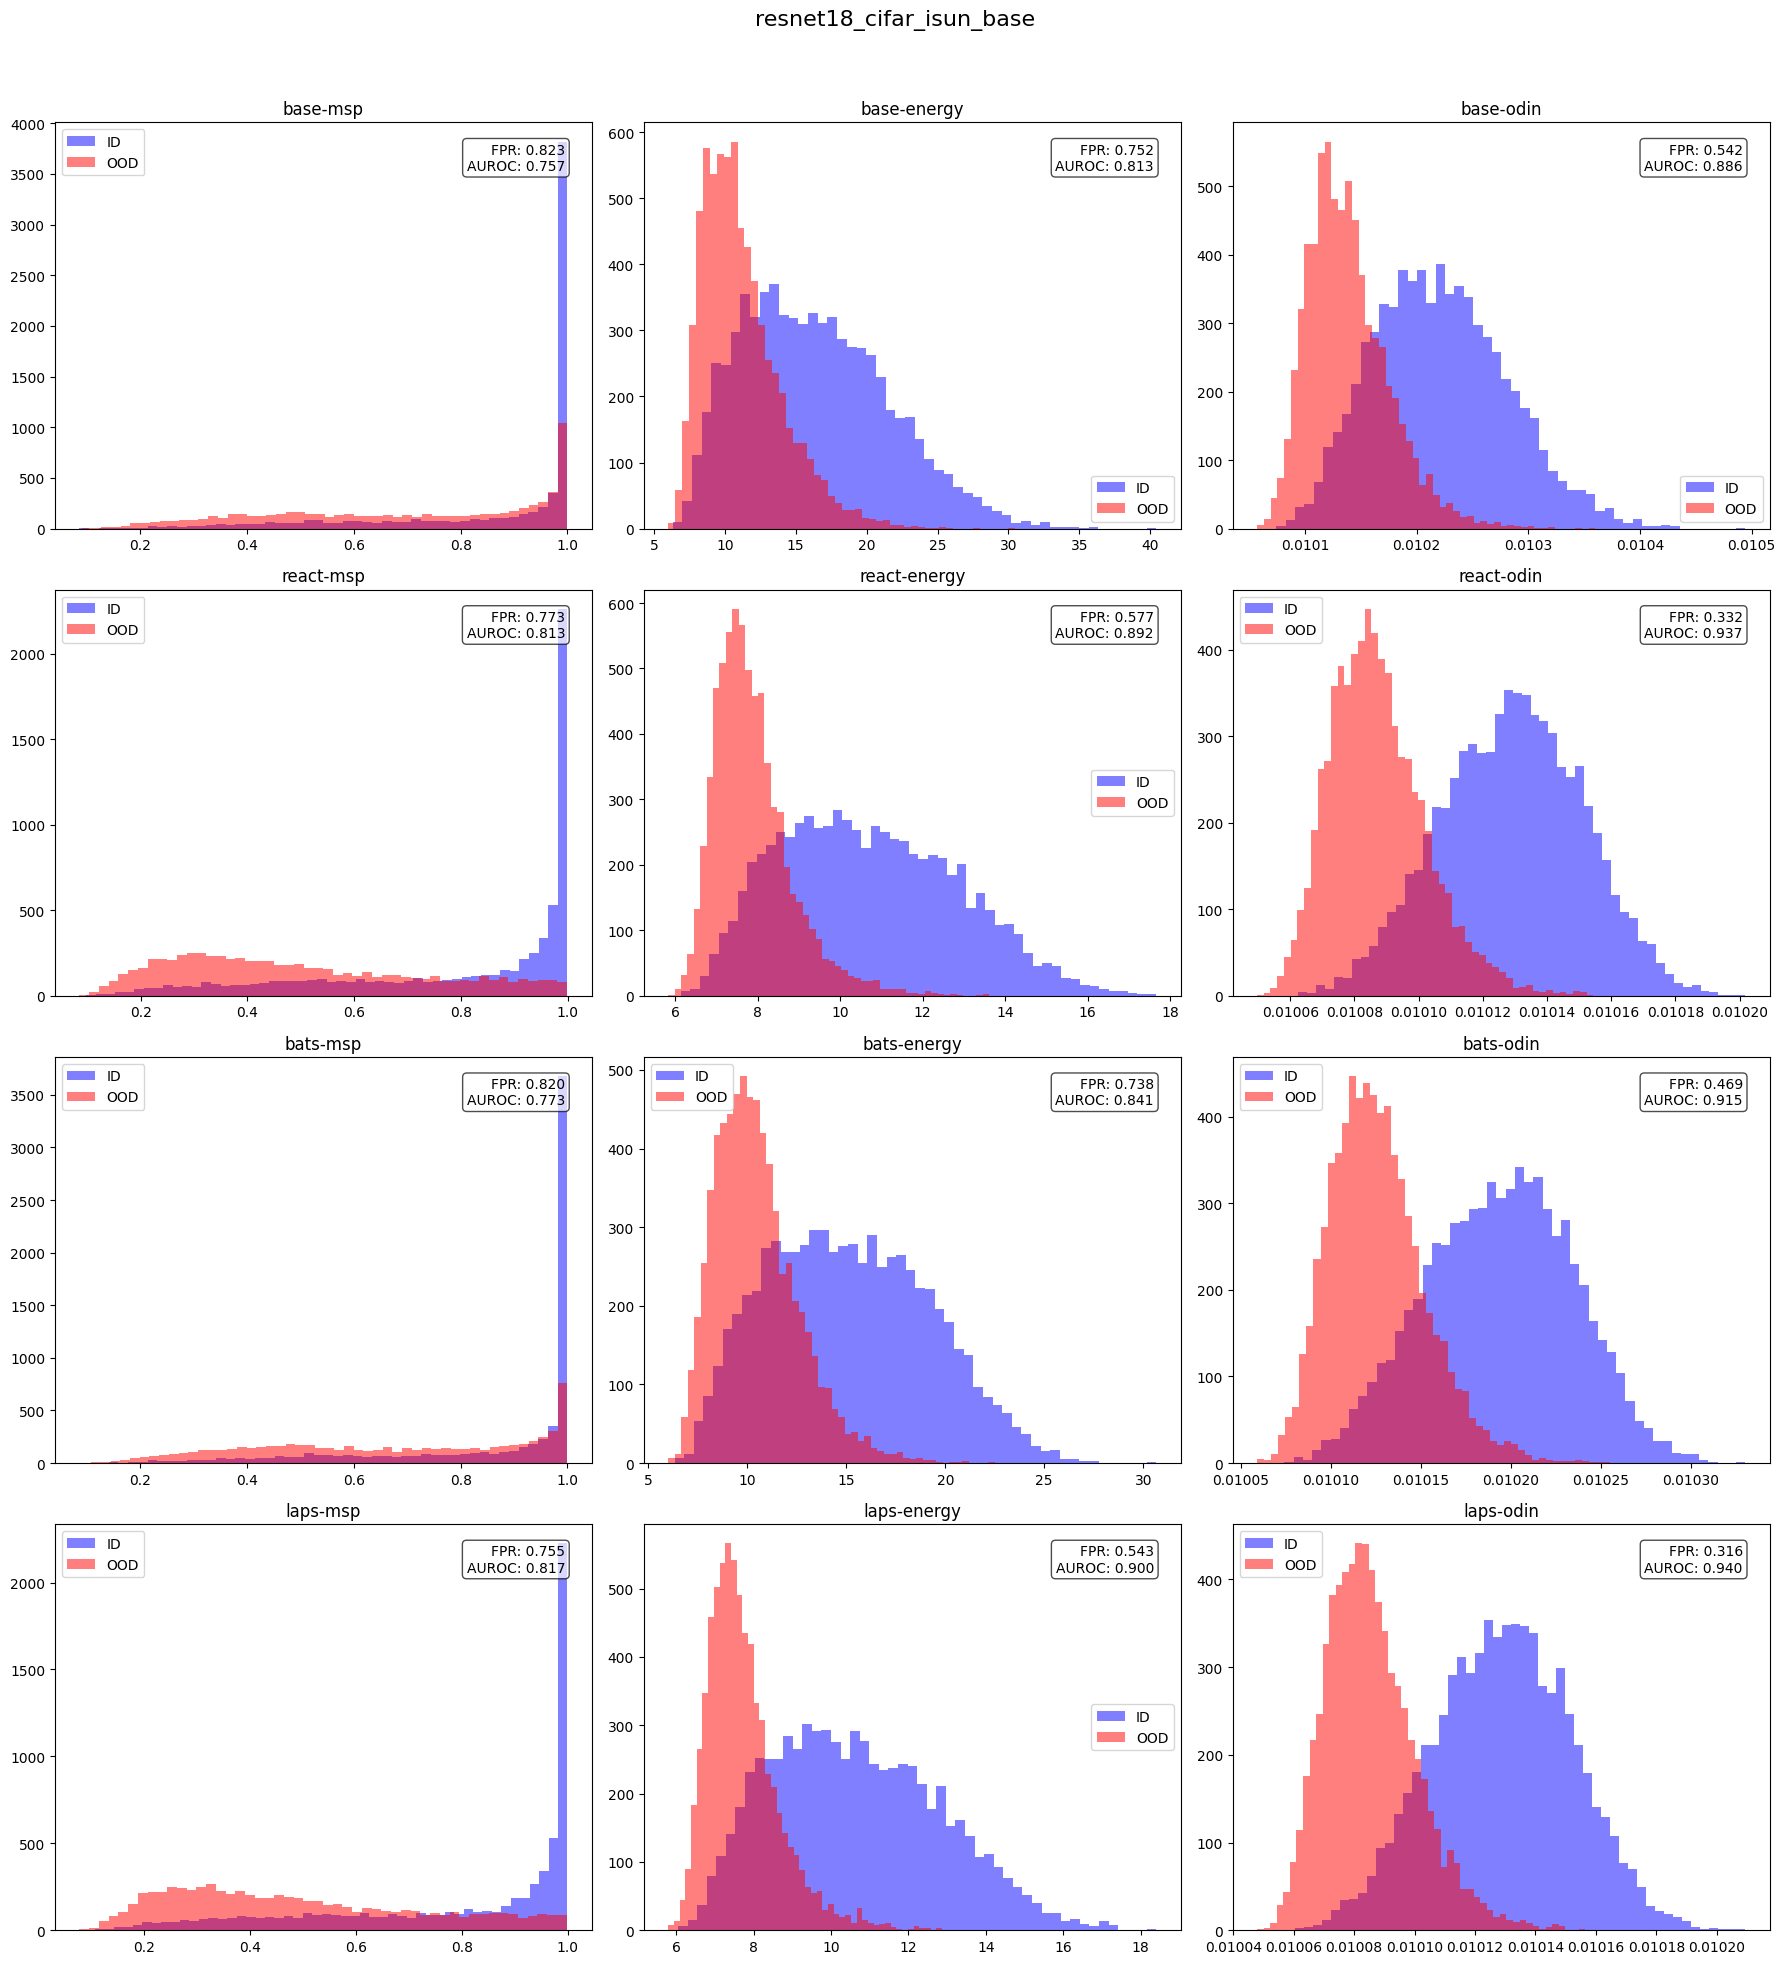

In [29]:
scores_in_all, scores_out_all=exp_base(config,forward_names=["base", "react", "bats", "laps"],methods=["msp", "energy", "odin"])

plot_score_dicts_subplots(scores_in_all, scores_out_all, title="resnet18_cifar_isun_base")

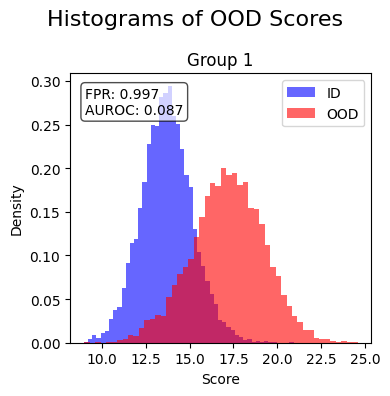

In [30]:
scores_in_all5=[]
scores_out_all5=[]
config["sblock"]=0
forward_func = get_forward(name="forward_features", config=config)
method="featurenorm"
n_iter=55
scores_in_all_i=get_all_scores( model,id_test_loader, forward_func,method, config, n_iter,accelerator)
scores_out_all_i=get_all_scores( model,ood_loader, forward_func,method, config, n_iter,accelerator)
scores_in_all5.append(scores_in_all_i)
scores_out_all5.append(scores_out_all_i)
plot_histograms(scores_in_all5, scores_out_all5, bins=50, title="Histograms of OOD Scores")


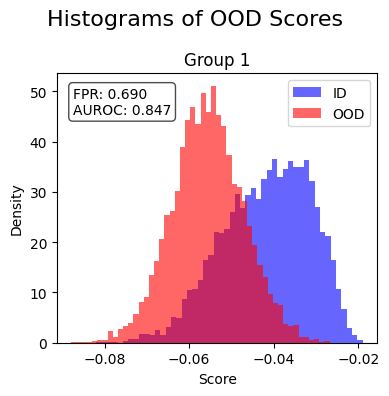

In [31]:
# CADRef 
scores_in_all2=[]
scores_out_all2=[]
config["sblock"]=0
forward_func = get_forward(name="cadref", config=config)
method="cadref"
n_iter=55
scores_in_all_i=get_all_scores( model,id_test_loader, forward_func,method, config, n_iter,accelerator)
scores_out_all_i=get_all_scores( model,ood_loader, forward_func,method, config, n_iter,accelerator)
scores_in_all2.append(scores_in_all_i)
scores_out_all2.append(scores_out_all_i)
plot_histograms(scores_in_all2, scores_out_all2, bins=50, title="Histograms of OOD Scores") 



<h1 style="color:green; text-shadow: 0 0 10px #ff00ff, 0 0 10px #ff00ff">
  OOD Dataset6: Places
</h1>

[Test] Loading OOD Dataloader for Places...
/Users/sunshine8641/Code/Data/Places
mps
ID Train Batch: x.shape=torch.Size([128, 3, 32, 32])
图像已保存到: Figs/x.png


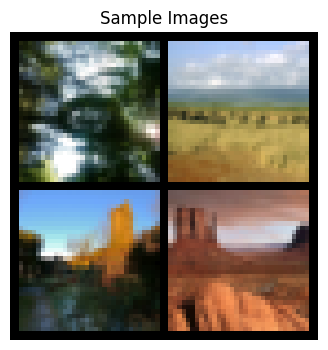

In [32]:
cfg["ood_dataset"]["name"]="Places"
accelerator,model,criterion,train_meters,test_meters,top_k,id_train_loader,id_test_loader,id_val_loader,ood_loader=initialize_experiment(config)
for batch in ood_loader:
    x, y = batch
    print(f"ID Train Batch: x.shape={x.shape}")
    break
show_images(x, y,mean,std, n=4)

[Test] Loading OOD Dataloader for Places...
/Users/sunshine8641/Code/Data/Places
mps
n_iter: 55


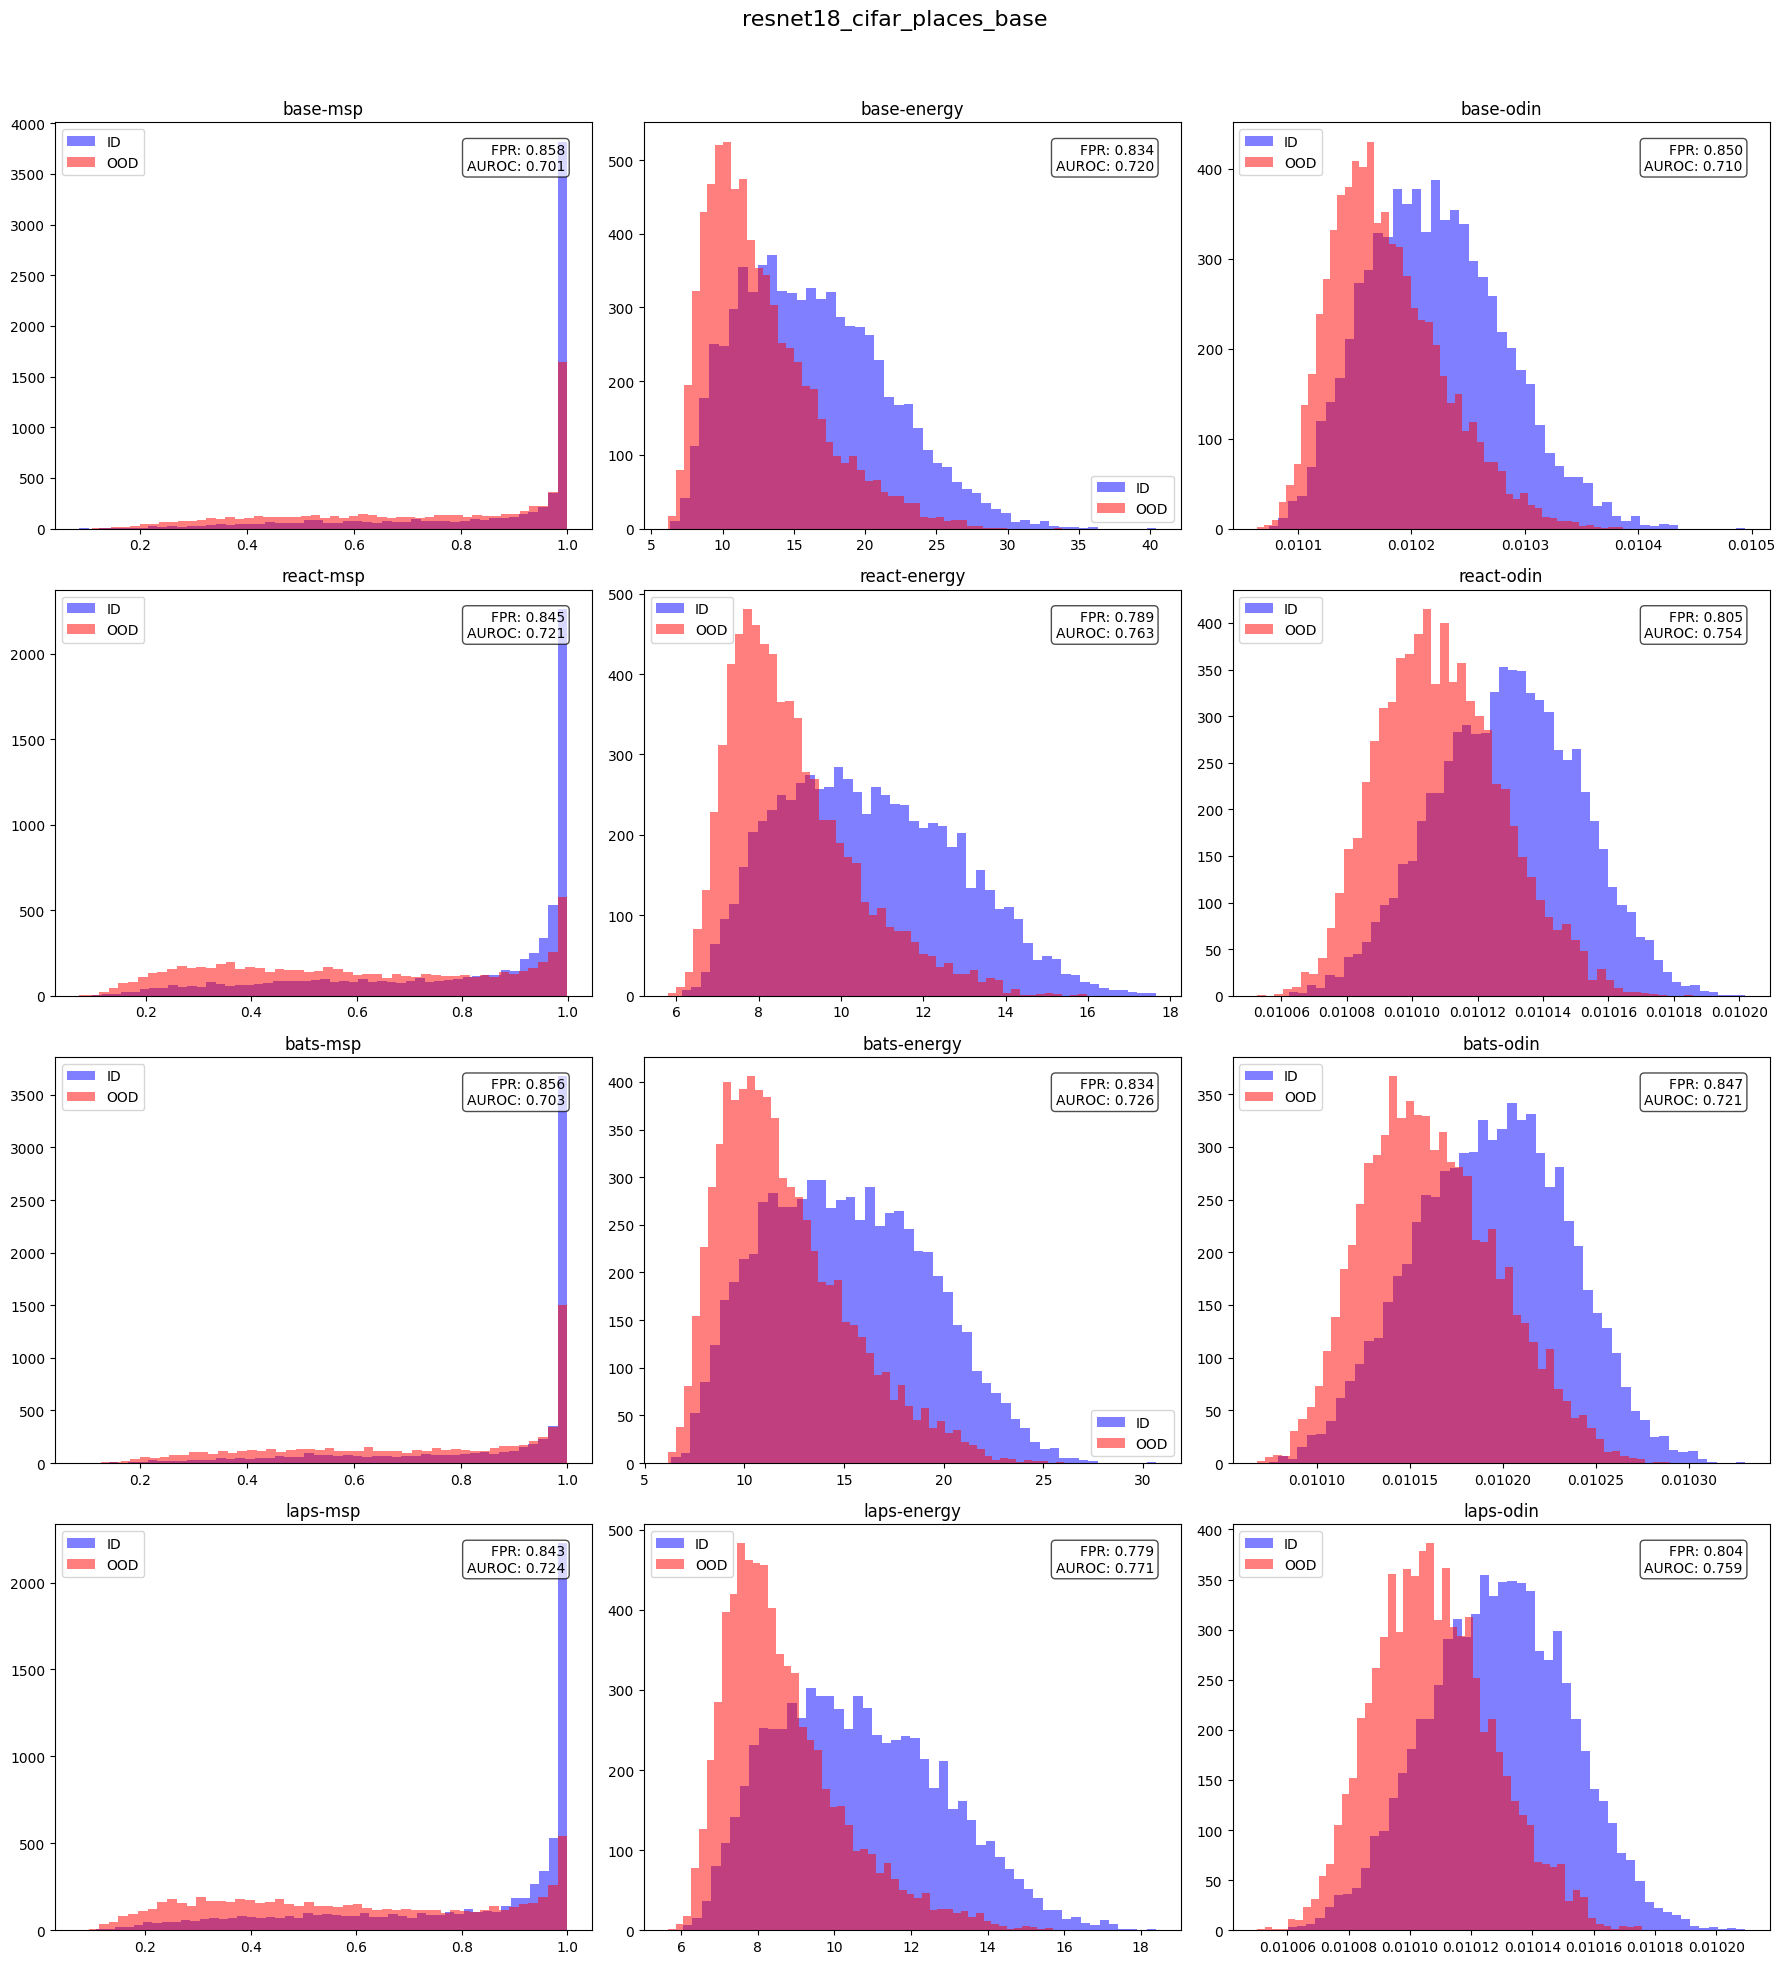

In [33]:
scores_in_all, scores_out_all=exp_base(config,forward_names=["base", "react", "bats", "laps"],methods=["msp", "energy", "odin"])

plot_score_dicts_subplots(scores_in_all, scores_out_all, title="resnet18_cifar_places_base")

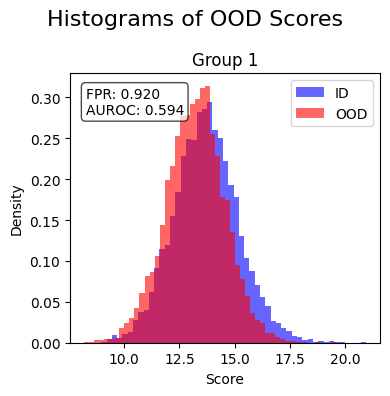

In [34]:
scores_in_all6=[]
scores_out_all6=[]
config["sblock"]=0
forward_func = get_forward(name="forward_features", config=config)
method="featurenorm"
n_iter=55
scores_in_all_i=get_all_scores( model,id_test_loader, forward_func,method, config, n_iter,accelerator)
scores_out_all_i=get_all_scores( model,ood_loader, forward_func,method, config, n_iter,accelerator)
scores_in_all6.append(scores_in_all_i)
scores_out_all6.append(scores_out_all_i)
plot_histograms(scores_in_all6, scores_out_all6, bins=50, title="Histograms of OOD Scores")


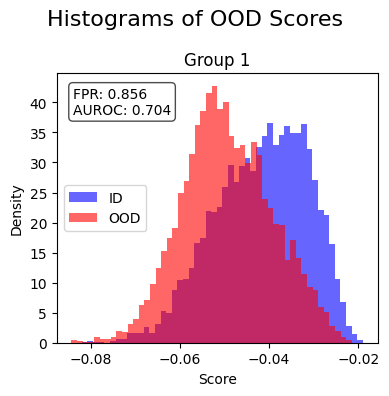

: 

In [ ]:
# CADRef 
scores_in_all2=[]
scores_out_all2=[]
config["sblock"]=0
forward_func = get_forward(name="cadref", config=config)
method="cadref"
n_iter=55
scores_in_all_i=get_all_scores( model,id_test_loader, forward_func,method, config, n_iter,accelerator)
scores_out_all_i=get_all_scores( model,ood_loader, forward_func,method, config, n_iter,accelerator)
scores_in_all2.append(scores_in_all_i)
scores_out_all2.append(scores_out_all_i)
plot_histograms(scores_in_all2, scores_out_all2, bins=50, title="Histograms of OOD Scores") 

